In [ ]:
%pip install pandas

110.30s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


  Using cached pandas-3.0.2-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached pandas-3.0.2-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (10.9 MB)
Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install matplotlib

  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17

In [3]:
%pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.2 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [2]:
# -------------------------------
# LOAD DATA
# -------------------------------
df = pd.read_csv("../cho_datasets/dataset.csv")

# FIX: handle missing values
df = df.fillna(0)

#print("Dataset loaded successfully!")
#print("\nColumns:\n", df.columns)

In [3]:
# -------------------------------
# DATA EXPLORATION
# -------------------------------
features_2 = [
    "category",
    "is_moas",
    "edit_distance",
    "prepending",
    "local_hege_freq",
    "global_hege_freq"
]

#df[features_2].head()

In [4]:
# mean, median, min, max
stats = df[features_2].describe().loc[['mean', '50%', 'min', 'max']]
stats.rename(index={'50%': 'median'}, inplace=True)

#range
stats.loc['range'] = stats.loc['max'] - stats.loc['min']

#mode
mode_df = df[features_2].select_dtypes(include=['number']).mode().iloc[0]
mode_df.name = 'mode'
mode_df_t = mode_df.to_frame().T

#combine everything into one table
final_stats = pd.concat([stats,mode_df_t])

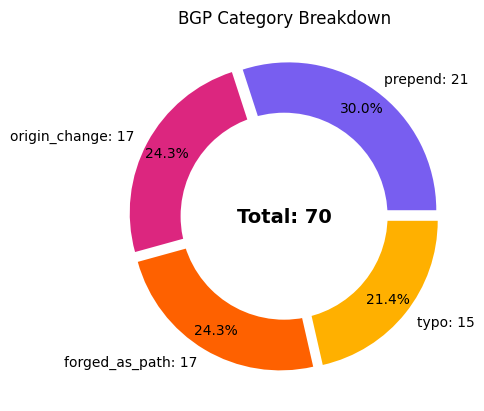

In [6]:
total = df['category'].count()
count_per_label = df['category'].value_counts()
colors = ['#785EF0', '#DC267F', '#FE6100', 
          '#FFB000']

#setup variables for donut chart
labels_count = []
for label, count in count_per_label.items():
    labels_count.append(f"{label}: {count}")
    
explode = (0.05, 0.05, 0.05, 0.05)

#create graph
plt.pie(count_per_label, colors=colors, labels= labels_count, autopct='%1.1f%%', pctdistance=0.85,
        explode=explode)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.text(0, 0, f"Total: {total}", ha='center', va='center', 
         fontsize=14, color='black', fontweight='bold')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('BGP Category Breakdown')

#plt.savefig(f"category_breakdown_2.png")
#plt.clf()

#display chart
plt.show()

In [7]:
# -------------------------------
# FEATURE DISTRIBUTIONS
# -------------------------------
#for feature in features:
plt.figure()
df["is_moas"].hist(bins=20, color="#E0AF3E")
plt.title(f"{"Is MOAS"} Distribution")
plt.xlabel("is_moas")
plt.ylabel("Frequency")
plt.savefig(f"is_moas_distribution_2.png")
plt.clf()

#plt.show()
#print("Saved: feature distribution graphs")


<Figure size 640x480 with 0 Axes>

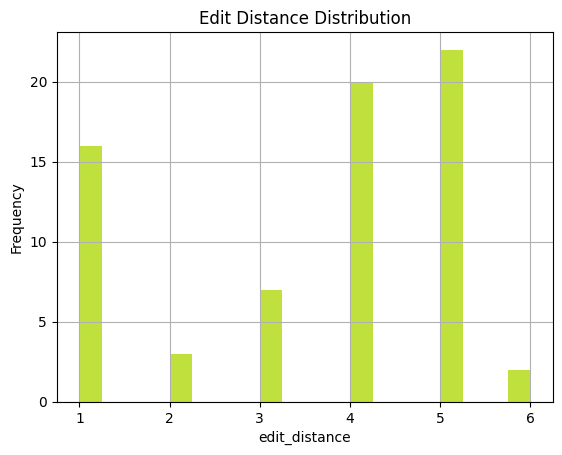

In [10]:
#take feature data and plot in histogram
plt.figure()
df["edit_distance"].hist(bins=20, color="#C0E03E")
plt.title(f"{"Edit Distance"} Distribution")
plt.xlabel("edit_distance")
plt.ylabel("Frequency")
#plt.savefig(f"edit_distance_distribution_2.png")
#plt.clf()
plt.show()
#print("Saved: feature distribution graphs")


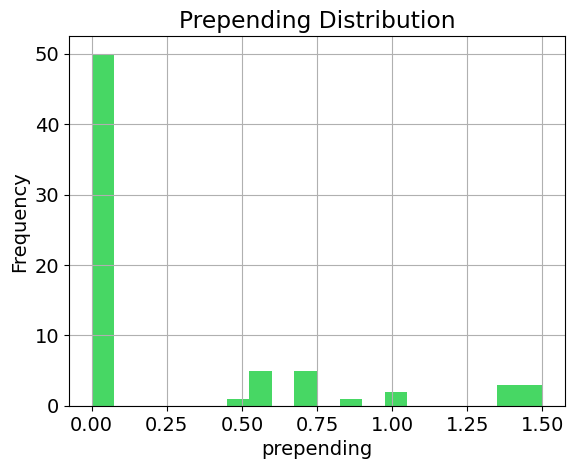

In [42]:
#take feature data and plot in histogram
plt.figure()
df["prepending"].hist(bins=20, color="#47D764")
plt.title(f"{"Prepending"} Distribution")
plt.xlabel("prepending")
plt.ylabel("Frequency")
plt.savefig(f"prepending_distribution_2.png")
#plt.clf()
#plt.show()
#print("Saved: feature distribution graphs")


In [12]:
#take feature data and plot in histogram
plt.figure()
df["local_hege_freq"].hist(bins=20, color="#47BAD7")
plt.title(f"{"Local Hegemony"} Distribution")
plt.xlabel("local_hege_freq")
plt.ylabel("Frequency")
plt.savefig(f"local_hege_freq_distribution_2.png")
plt.clf()
#plt.show()
#print("Saved: feature distribution graphs")


<Figure size 640x480 with 0 Axes>

In [41]:
#take feature data and plot in histogram
plt.figure()
df["global_hege_freq"].hist(bins=20, color="#9D47D7")
plt.title(f"{"Global Hegemony"} Distribution")
plt.xlabel("global_hege_freq")
plt.ylabel("Frequency")
plt.savefig(f"global_hege_freq_distribution_2.png")
plt.clf()
#plt.show()
#print("Saved: feature distribution graphs")


<Figure size 640x480 with 0 Axes>

In [14]:
# -------------------------------
# SELECT FEATURES 
# -------------------------------
features = [
    "is_moas",
    "edit_distance",
    "prepending",
    "local_hege_freq",
    "global_hege_freq"
]

X = df[features]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

y = df["category"]

In [15]:
# -------------------------------
# TRAIN / TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [16]:
# -------------------------------
# MODELS
# -------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
}

results = {}

In [17]:
# -------------------------------
# TRAIN & EVALUATE
# -------------------------------
plt.rcParams.update({'font.size': 14}) 
for name, model in models.items():
    print("\n========================")
    print(f"Model: {name}")
    print("========================")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    report = classification_report(y_test, y_pred)
    report_output = (
                f"\n========================\n"
                f"Model: {name}\n"
                f"========================\n"
                f"Accuracy: {acc}\n"
                f"\nClassification Report:\n"
                f"{report}\n"
            )

    with open(f"{name}_model_results_2.txt", "a") as f:
        f.write(report_output)


    print("Accuracy:", acc)
    print("\nClassification Report:\n")
    print(report)


Model: Logistic Regression
Accuracy: 0.9047619047619048

Classification Report:

                precision    recall  f1-score   support

forged_as_path       1.00      1.00      1.00         6
 origin_change       0.83      0.83      0.83         6
       prepend       1.00      0.83      0.91         6
          typo       0.75      1.00      0.86         3

      accuracy                           0.90        21
     macro avg       0.90      0.92      0.90        21
  weighted avg       0.92      0.90      0.91        21


Model: KNN
Accuracy: 0.9047619047619048

Classification Report:

                precision    recall  f1-score   support

forged_as_path       1.00      1.00      1.00         6
 origin_change       0.83      0.83      0.83         6
       prepend       1.00      0.83      0.91         6
          typo       0.75      1.00      0.86         3

      accuracy                           0.90        21
     macro avg       0.90      0.92      0.90        21
  weigh

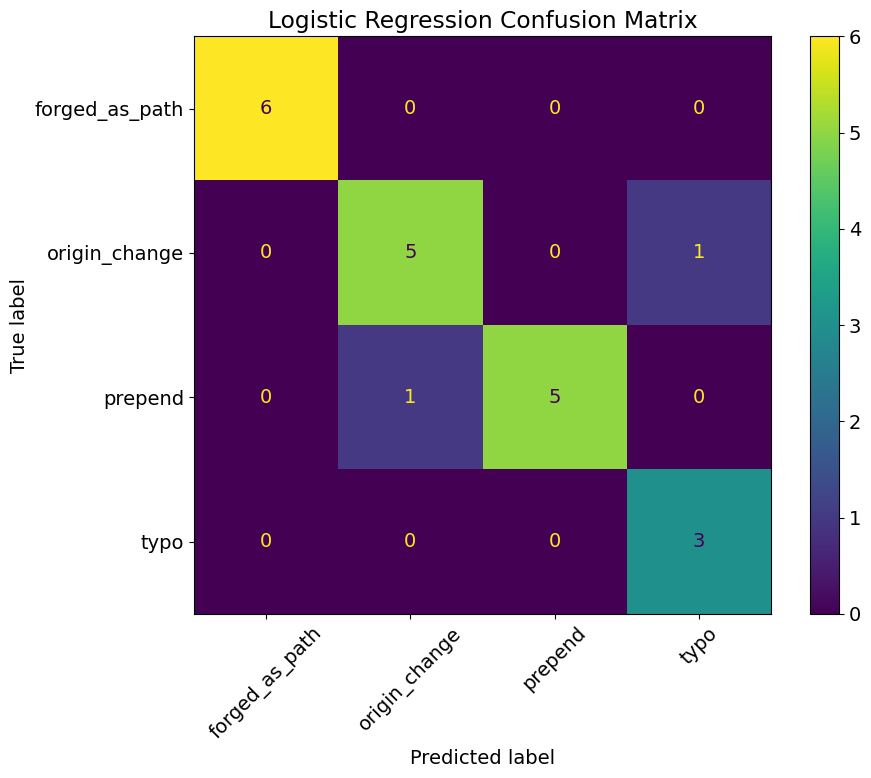

In [39]:
# -------------------------------
# CONFUSION MATRIX
# -------------------------------
LR_model_name = "Logistic Regression"
LR_model = LogisticRegression(max_iter=1000)

#train model
LR_model.fit(X_train, y_train)
LR_y_pred = LR_model.predict(X_test)

#create confusion matrix
fig, ax = plt.subplots(figsize=(10, 8)) 
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    LR_y_pred, 
    xticks_rotation=45,  
    ax=ax                 
)

plt.title(f"{LR_model_name} Confusion Matrix")
plt.tight_layout()       
plt.savefig(f"{name}_confusion_matrix_2.png")
#plt.clf()

#plt.show()


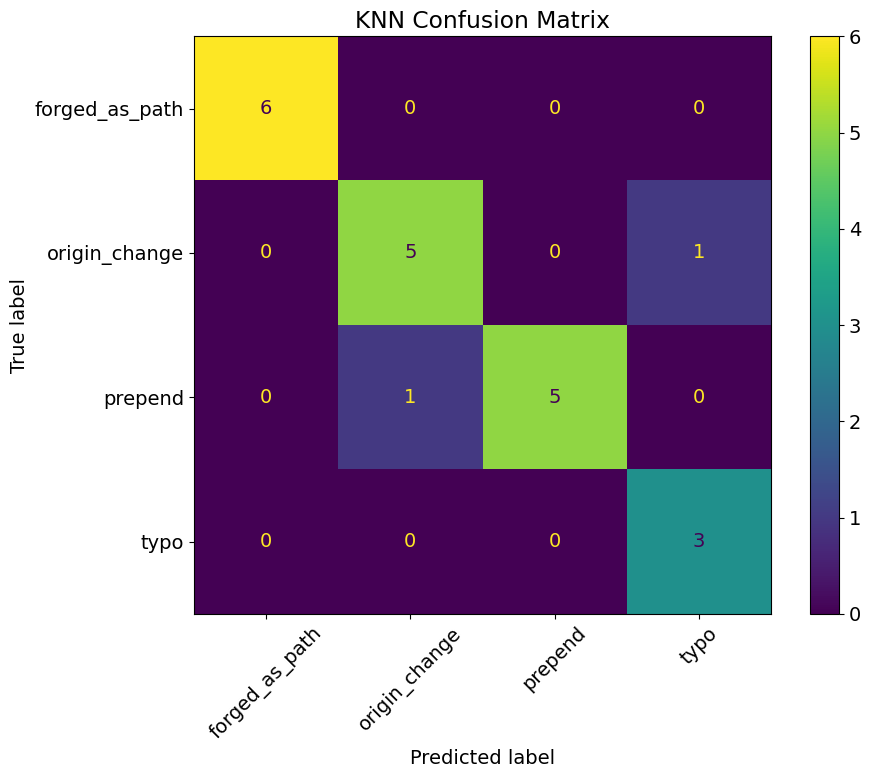

In [38]:
#for name, model in models.items():
KNN_model_name = "KNN"
KNN_model = KNeighborsClassifier(n_neighbors=3)

#train model
KNN_model.fit(X_train, y_train)
KNN_y_pred = KNN_model.predict(X_test)

#create confusion matrix
fig, ax = plt.subplots(figsize=(10, 8)) 
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    KNN_y_pred, 
    xticks_rotation=45,  
    ax=ax                 
)

plt.title(f"{KNN_model_name} Confusion Matrix")
plt.tight_layout()       
plt.savefig(f"{name}_confusion_matrix_2.png")
#plt.clf()

#plt.show()


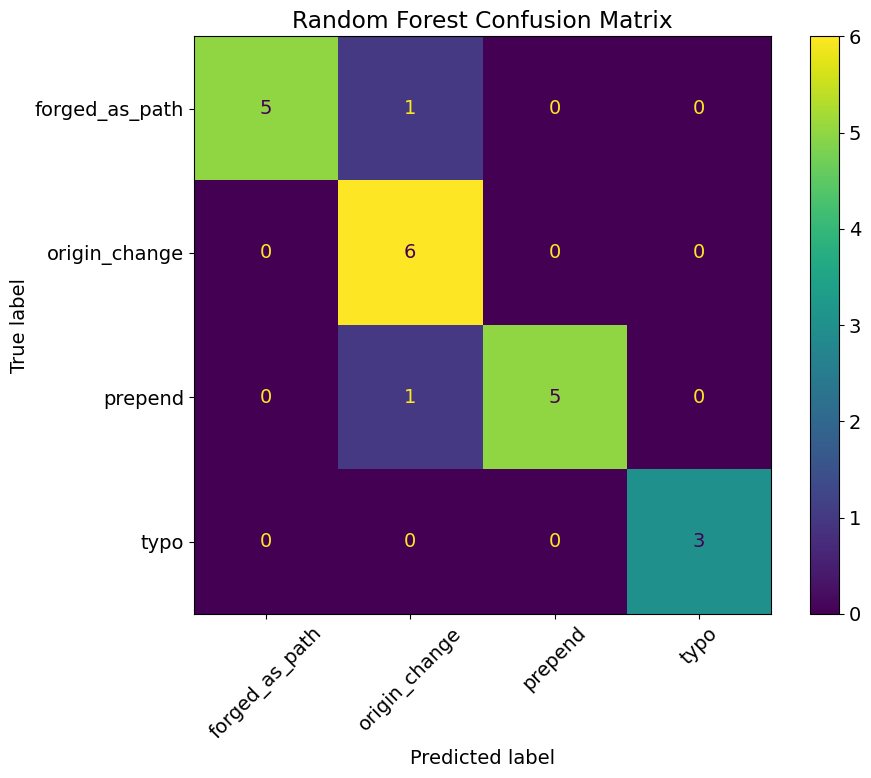

In [35]:
#for name, model in models.items():
RF_model_name = "Random Forest"
RF_model = RandomForestClassifier()

#train model
RF_model.fit(X_train, y_train)
RF_y_pred = RF_model.predict(X_test)

#create confusion matrix
fig, ax = plt.subplots(figsize=(10, 8)) 
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    RF_y_pred, 
    xticks_rotation=45,  
    ax=ax                 
)

plt.title(f"{RF_model_name} Confusion Matrix")
plt.tight_layout()       
plt.savefig(f"{name}_confusion_matrix_2.png")
#plt.clf()

#plt.show()


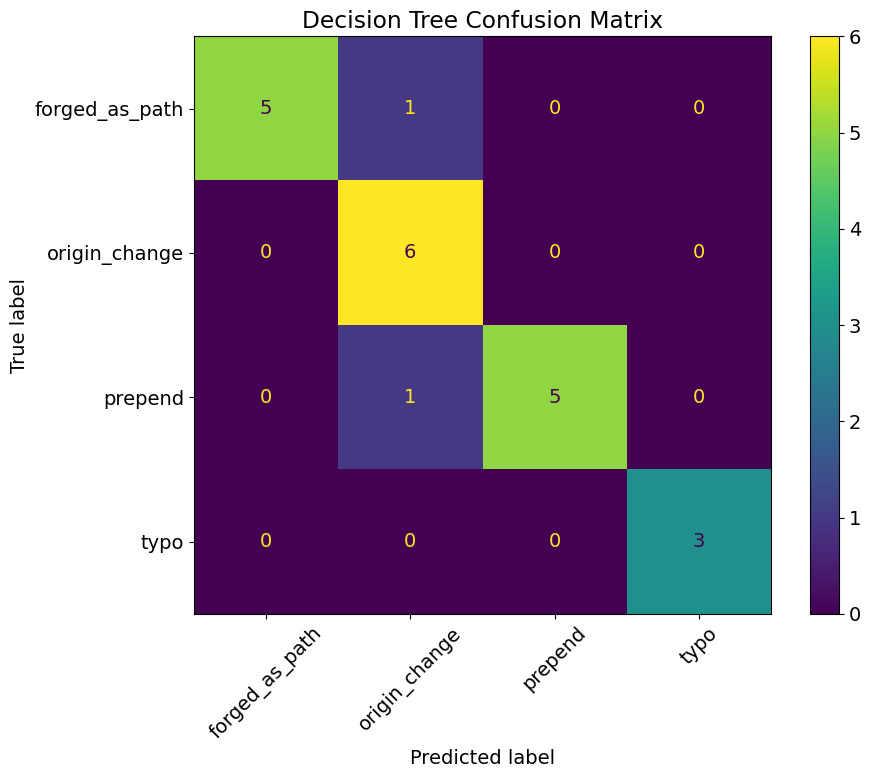

In [36]:
#for name, model in models.items():
DT_model_name = "Decision Tree"
DT_model = DecisionTreeClassifier()

#train model
DT_model.fit(X_train, y_train)
DT_y_pred = RF_model.predict(X_test)

#create confusion matrix
fig, ax = plt.subplots(figsize=(10, 8)) 
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    DT_y_pred, 
    xticks_rotation=45,  
    ax=ax                 
)

plt.title(f"{DT_model_name} Confusion Matrix")
plt.tight_layout()       
plt.savefig(f"{name}_confusion_matrix_2.png")
#plt.clf()

#plt.show()


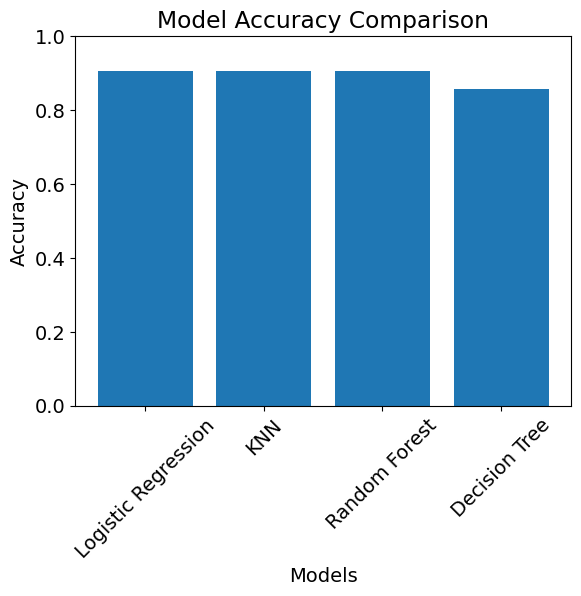

In [37]:
# -------------------------------
# MODEL COMPARISON
# -------------------------------
model_names = list(results.keys())
accuracies = list(results.values())

plt.figure()
plt.bar(model_names, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.savefig("model_comparison_2.png")
#plt.clf()
#plt.show()